# Formats et Entrées/Sorties - Bases 1 - 23/02/2026

Dans ce notebook, nous verrons comment ouvrir des images numériques en Python, les afficher, et gérer des premières manipulations.

Comme toujours, toutes les cellules peuvent être executées dans l'ordre, mais essayez de prédire la sortie de chaque cellule avant de l'exécuter.
N'hésitez pas à jouer avec le code, le bidouiller pour tester des alternatives — c'est l'un des grands avantages d'utiliser un notebook.

Nous allons découvrir les deux librairies principales pour la manipulation d'images numériques : `OpenCV` et `matplotlib`.

❗ Il faut d'abord les installer dans votre environnement `conda`:
````
conda activate unige
conda install conda-forge::opencv
conda install conda-forge::matplotlib


Une fois ceci fait, nous pouvons les importer comme ceci :

In [1]:
import cv2
import matplotlib.pyplot as plt

❗ Rappelez-vous que pour accéder aux commandes d'une librairie, il faut en faire figurer le préfixe. Par exemple, la fonction `imshow()` d'OpenCV s'appelle via:
`cv2.imshow()`

## 1. Ouvrir une image

Une image numérique raster peut s'ouvrir facilement par OpenCV via `imread()`

❓ En vous rappelant le cours, quel genre de données (structure, représentation) vous attendez-vous à trouver ?

Prenons-ici une image test, appelée `feneon.jpg`

In [2]:
img = cv2.imread("data/feneon.jpg")

In [4]:
img.shape

(1597, 1597, 3)

❓ Quel _type_ de données est-ce ? 

❓ Quelles en sont ses dimensions ?

In [ ]:
# Votre réponse ici

Une fois dans une variable, cette image peut s'afficher via la fonction `imshow()` de `matplotlib` (!), qui prend en argument toute représentation mathématique raster.

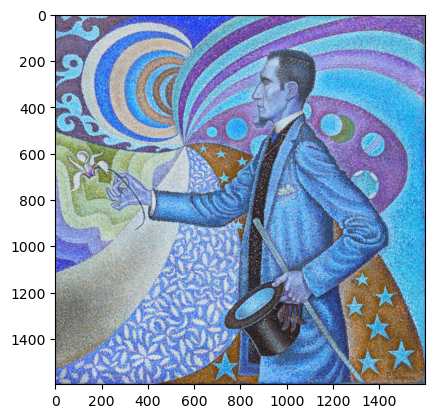

In [5]:
plt.imshow(img)

## 2. Structure des données

### 2.1. Dimensions de l'image
❓ Quand on ouvre l'image, un problème visuel est évident. Quel est le problème ici selon vous ?


In [ ]:
# Votre réponse ici

Revenons aux dimensions de l'objet `img`.

❓ Que représentent ces dimensions ?

In [ ]:
# Votre réponse ici

❓ Essayez de les visualiser de manière séparée. (Faites bien attention à la _structure_ de l'image)

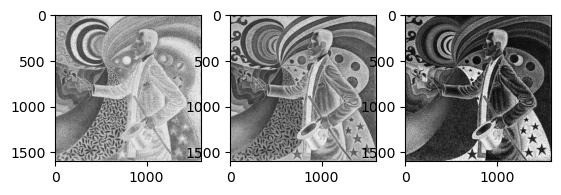

In [6]:
fig,ax = plt.subplots(1, 3)

for i in range(3):
    ax[i].imshow(img[:,:,i], cmap='Greys')

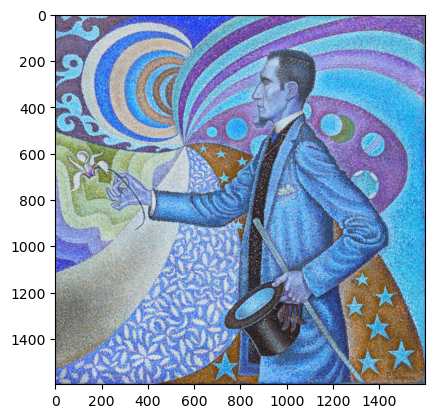

In [7]:
plt.imshow(img)

### 2.2. Conversion de couleurs

Un problème fréquent est celui de la conversion des couleurs : il faut changer de format de représentation colorimétrique.

C'est un problème courant et ses solutions sont donc déjà implémentée dans la librairie directement via la structure: 

`cv2.cvtColor(X, <type_de_conversion>)`

Ici, nous voulons passer du BGR au RGB, et l'opération de conversion s'appelle donc : `cv2.COLOR_BGR2RGB`.

❓ À vous de l'implémenter : faites la transformation, et affichez le résultat.

In [8]:
# Votre réponse ici

img_bgr = cv2.imread("./data/feneon.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


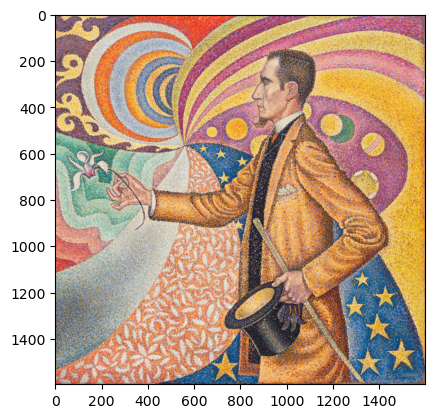

In [9]:
plt.imshow(img_rgb)

Il existe une longue liste de transformation pré-existantes : [voir le site d'OpenCV](https://docs.opencv.org/3.4/d8/d01/group__imgproc__color__conversions.html)

❓ Essayez de trouver et d'appliquer la transformation d'une image couleur en image en niveaux de gris.

In [11]:
# Votre réponse ici
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

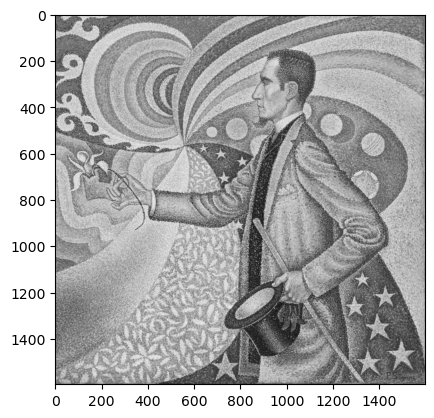

In [ ]:
plt.imshow(cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB))

Pour bien vérifier que l'opération a fonctionné, il y a deux solutions : (1) la confirmation visuelle, (2) la confirmation numérique.

❓ (1. Confirmation visuelle) Affichez donc l'image après transformation :

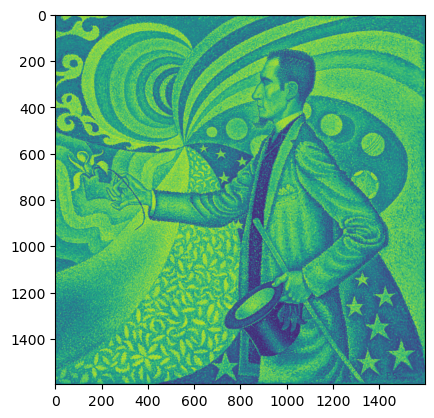

In [17]:
# Votre réponse ici
plt.imshow(img_gray)

❓ (2. Confirmation numérique) Quelle sont les dimensions de l'image avant la transformation ? Et après ? 

Quelle est la valeur du premier pixel avant la transformation ? Et après ?

In [21]:
# Votre réponse ici
img_gray.shape


(1597, 1597)

## 3. Annotations

Nous avons vu durant le cours que les informations raster et vecteur représentaient des choses différentes et pouvaient se superposer. Essayons de le mettre en place, ici.

Un cas typique, que nous verrons plus tard dans le semestre, est celui d'une information extraite automatiquement —- par exemple, un réseau profond vous donne la position d'un visage.

Les coordonnées calculées sont donc typique d'une information vectorielle (ce sont des points géométriques). Mais nous pouvons vouloir la superposer à l'image raster.

❗ Attention, dans OpenCV, les axes commencent en haut à gauche (et non, comme dans une représentation cartésienne usuelle en bas à gauche). Ceci peut être source de confusion, surtout quand les axes ne sont pas affichés :

In [23]:
img = img_rgb

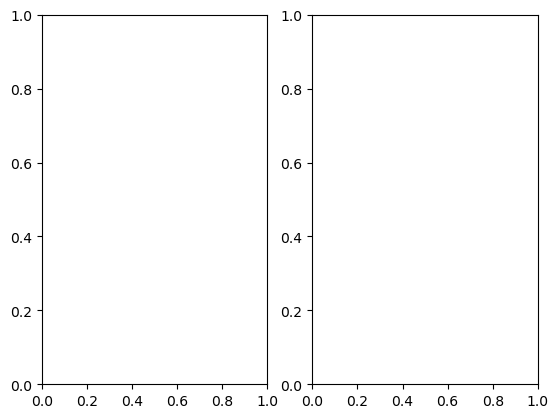

In [25]:
fig, axes = plt.subplots(1, 2)

/var/folders/h0/0v0s48pj41zdnzdy7333vb4m0000gn/T/ipykernel_26292/2501900515.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


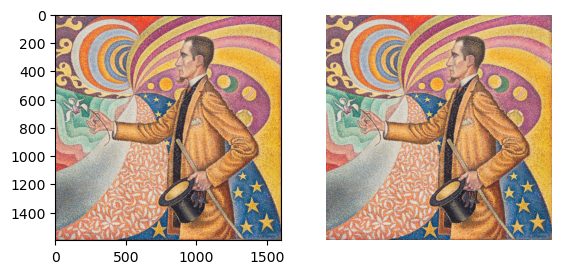

In [24]:
fig, axes = plt.subplots(1, 2)
axes[0].imshow(img)
axes[1].imshow(img)
axes[1].axis('off')
fig.show()

Admettons que la position du visage qu'un algorithme tiers vous retourne soit entre les points 
- en bas à gauche : (850, 500)
- en haut à droite : (1120, 150)

Une première solution est d'utiliser la fonction `cv2.rectangle` d'OpenCV qui sur-impose un rectangle.

Attention, la fonction `cv2.rectangle` modifie l'image originale. Veillez à bien faire une copie si vous souhaitez garder l'apparence originale en mémoire.

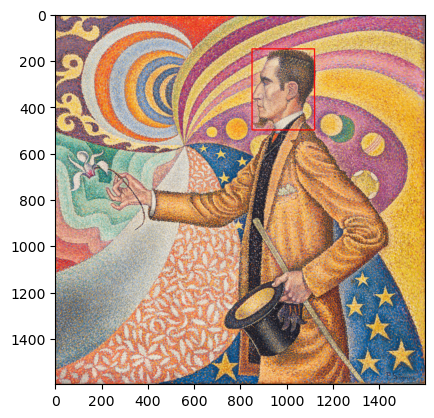

In [31]:
start_point = (850, 500)
end_point = (1120, 150)
color = (255, 0, 0)
thickness = 3

# Ici, on modifie le vecteur de l'image:
cv2.rectangle(img, start_point, end_point, color, thickness)

# Que l'on peut afficher ainsi
plt.imshow(img)

❓ L'image obtenue est-elle une image vecteur ou raster ?

Une autre méthode, moins invasive consiste à traiter la figure comme une "toile" sur laquelle on peut ajouter des éléments via les fonctions de la librairie `matplotlib`.

Pour dessiner un rectangle, la sous-librairie est `patches`, et la fonction correspondante `Rectangle`.

Nous verrons ensemble ce que signifient les lignes de préparation, et les variables `fig` et `ax`. Pour le moment, il suffit de changer les valeurs des arguments de la fonction `Rectangle`.

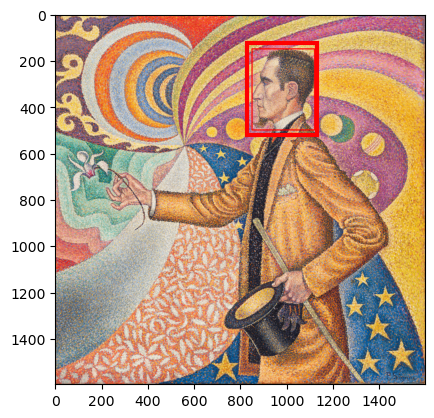

In [33]:

import matplotlib.patches as patches

fig, ax = plt.subplots()
ax.imshow(img)

rect = patches.Rectangle(
    (830, 120),     # (x, y)
    300,           # largeur
    400,           # hauteur
    linewidth=3,
    edgecolor='r',
    facecolor='none'
)

ax.add_patch(rect)
plt.show()

❓ Pouvez-vous deviner ce qui ne va pas dans cet exemple ? Que faut-il changer pour que l'image convienne ?

In [ ]:
# Votre réponse ici

❓ De nouveau, l'image obtenue est-elle une image vecteur ou raster ?

In [ ]:
# Votre réponse ici

## 4. Exporter une image

L'export d'images ouvertes, manipulées, modifiées passe par `matplotlib`, et sa fonction `savefig`.

Pour ce faire, il suffit d'appeler :

`plt.savefig(<nom_du_fichier>.<extension>)`

Selon l'extension choisie et les données affichées, l'image sera soit vectorielle, soit raster, soit les deux.

❗ Attention, cette fonction exporte la dernière image ouverte.


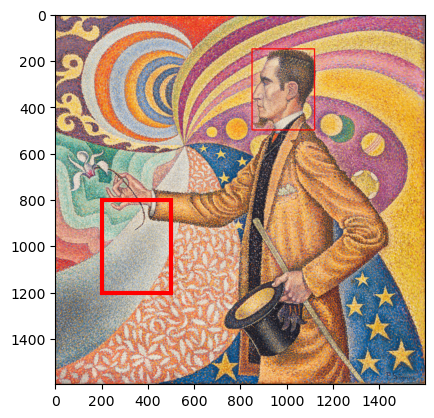

In [34]:
fig, ax = plt.subplots()
ax.imshow(img)
rect = patches.Rectangle(
    (200, 800),     # (x, y)
    300,           # largeur
    400,           # hauteur
    linewidth=3,
    edgecolor='r',
    facecolor='none'
)
ax.add_patch(rect)


plt.savefig('export.png')

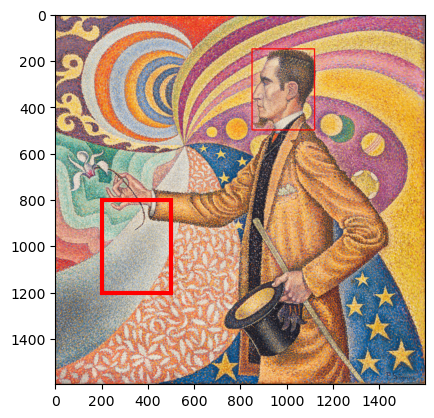

In [35]:
fig, ax = plt.subplots()
ax.imshow(img)
rect = patches.Rectangle(
    (200, 800),     # (x, y)
    300,           # largeur
    400,           # hauteur
    linewidth=3,
    edgecolor='r',
    facecolor='none'
)
ax.add_patch(rect)

plt.savefig('export.pdf')

❓ Une dernière fois, l'image obtenue est-elle une image vecteur ou raster ?

In [ ]:
# Votre réponse ici